# scVI embeddings analysis

UMAP of cell types colored by organ

In [2]:
# Minimal setup: imports and DATA_DIR discovery
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

_notebook_dir = os.path.dirname(os.path.abspath('scvi_embedding_analysis.ipynb'))
DATA_DIR = '../data/scvi'
parquet_files = sorted(glob.glob(os.path.join(DATA_DIR, '*_cell_type_embeds.parquet')))
if not parquet_files:
    raise FileNotFoundError(f'No *_cell_type_embeds.parquet files found in {DATA_DIR}.')

# Load and concatenate
dfs = []
for path in parquet_files:
    df = pd.read_parquet(path)
    df['source'] = os.path.basename(path).replace('_cell_type_embeds.parquet', '')
    dfs.append(df)
data = pd.concat(dfs, ignore_index=True)
scvi_cols = [c for c in data.columns if c.startswith('scvi_')]
if len(scvi_cols) == 0:
    raise ValueError('No scvi_ columns found in parquet files')
X = data[scvi_cols].values.astype(float)
labels = data['cell_ontology_class'].values
sources = data['source'].values
label_ids = LabelEncoder().fit_transform(labels)

/Users/irithkatiyar/Desktop/hst506/genai4bio-project/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


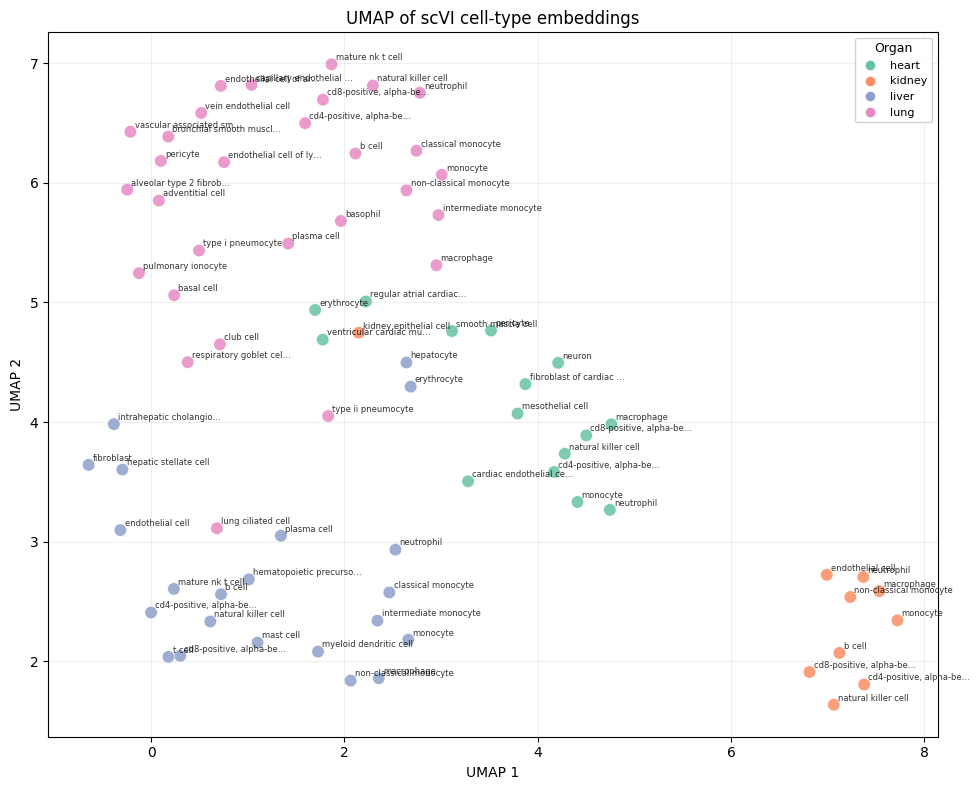

In [4]:
# UMAP plot: cell-type embeddings colored by organ (single panel)
ORGAN_COLORS = [
    '#66c2a5',  # teal
    '#fc8d62',  # orange
    '#8da0cb',  # blue
    '#e78ac3',  # pink
    '#a6d854',  # green
    '#ffd92f',  # yellow
    '#e5c494',  # tan
]

try:
    import umap
except Exception as e:
    raise ImportError('umap-learn is required for this notebook (pip install umap-learn)') from e

reducer = umap.UMAP(n_components=2, n_neighbors=min(15, max(2, len(X)-1)), min_dist=0.3, random_state=42)
X_umap = reducer.fit_transform(X)

# Derive organ names from source entries
organs = np.array([s.rsplit('_', 1)[0] for s in sources])
unique_organs = np.unique(organs)
organ_ids = LabelEncoder().fit_transform(organs)

if len(ORGAN_COLORS) < len(unique_organs):
    raise ValueError(f'ORGAN_COLORS has {len(ORGAN_COLORS)} entries but there are {len(unique_organs)} organs: {unique_organs.tolist()}')

point_colors = [ORGAN_COLORS[i] for i in organ_ids]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=point_colors, s=80, alpha=0.85, edgecolors='white', linewidths=0.4)
for x, y, lbl in zip(X_umap[:, 0], X_umap[:, 1], labels):
    short = lbl[:22] + ('…' if len(lbl) > 22 else '')
    ax.annotate(short, (x, y), fontsize=6, alpha=0.8, xytext=(3, 3), textcoords='offset points')

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=ORGAN_COLORS[i], markersize=8, label=organ)
           for i, organ in enumerate(unique_organs)]
ax.legend(handles=handles, title='Organ', fontsize=8, title_fontsize=9, loc='best', framealpha=0.9)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of scVI cell-type embeddings')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

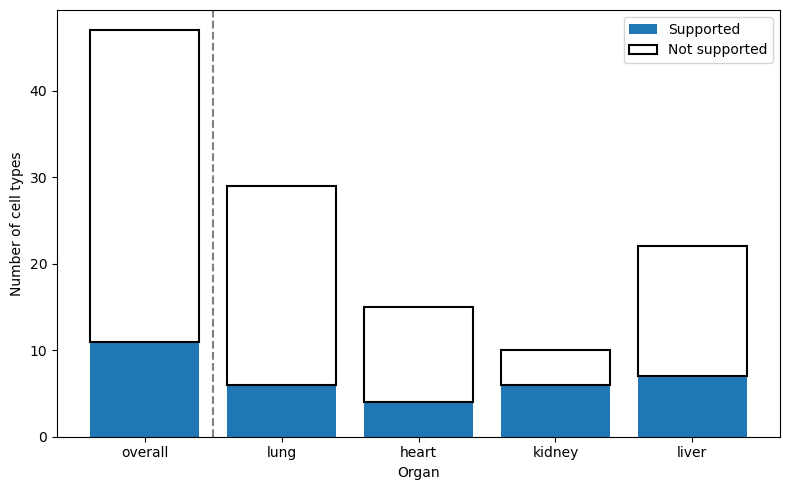

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Load supported cell types
# -------------------------
with open("../data/metadata/alphagenome_supported_cell_types.txt") as f:
    supported_ids = set(line.strip() for line in f if line.strip())

# -------------------------
# Organs and file paths
# -------------------------
organs = ["lung", "heart", "kidney", "liver"]
files = {organ: f"../data/metadata/{organ}_10X_cell_type_map.csv" for organ in organs}

# -------------------------
# Compute counts
# -------------------------
results = {}

all_ids = set()

for organ, path in files.items():
    df = pd.read_csv(path)
    ids = set(df["cell_ontology_id"])
    
    supported = ids & supported_ids
    unsupported = ids - supported_ids
    
    results[organ] = {
        "supported": len(supported),
        "unsupported": len(unsupported),
        "total": len(ids)
    }
    
    all_ids.update(ids)

# Overall
overall_supported = len(all_ids & supported_ids)
overall_unsupported = len(all_ids - supported_ids)

results = {"overall": {
    "supported": overall_supported,
    "unsupported": overall_unsupported,
    "total": len(all_ids)
}} | results  # prepend overall

# -------------------------
# Prepare plotting data
# -------------------------
labels = list(results.keys())
supported_vals = [results[k]["supported"] for k in labels]
unsupported_vals = [results[k]["unsupported"] for k in labels]

x = range(len(labels))

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 5))

# Supported (filled)
plt.bar(x, supported_vals, label="Supported")

# Unsupported (outlined, stacked on top)
plt.bar(
    x,
    unsupported_vals,
    bottom=supported_vals,
    label="Not supported",
    facecolor='none',
    edgecolor='black',
    linewidth=1.5
)

# Dotted separator after "overall"
plt.axvline(x=0.5, linestyle='--', color='gray')

# Labels and formatting
plt.xticks(x, labels)
plt.xlabel("Organ")
plt.ylabel("Number of cell types")
plt.legend()

plt.tight_layout()
plt.show()

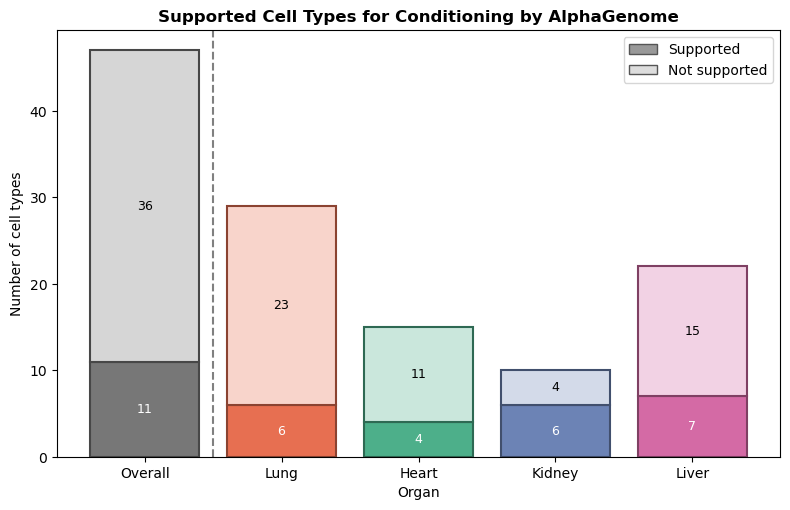

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------
# Paths
# -------------------------
ROOT = "../data/metadata/"

# -------------------------
# Color scheme
# -------------------------
ORGAN_COLORS = {
    'overall': '#777777',
    'heart': '#4daf8a',
    'lung' : '#e76f51',
    'kidney': '#6c83b5',
    'liver': '#d46aa5',
}

def darken_color(color, factor=0.6):
    rgb = mcolors.to_rgb(color)
    return tuple(c * factor for c in rgb)

def lighten_color(color, factor=0.4):
    """Blend color toward white."""
    rgb = mcolors.to_rgb(color)
    return tuple(1 - (1 - c) * (1 - factor) for c in rgb)

# -------------------------
# Load supported IDs
# -------------------------
with open(ROOT + "alphagenome_supported_cell_types.txt") as f:
    supported_ids = set(line.strip() for line in f if line.strip())

# -------------------------
# Load organ data
# -------------------------
organs = ["lung", "heart", "kidney", "liver"]
files = {organ: ROOT + f"{organ}_10X_cell_type_map.csv" for organ in organs}

results = {}
all_ids = set()

for organ, path in files.items():
    df = pd.read_csv(path)
    ids = set(df["cell_ontology_id"])
    
    supported = ids & supported_ids
    unsupported = ids - supported_ids
    
    results[organ] = {
        "supported": len(supported),
        "unsupported": len(unsupported),
    }
    
    all_ids.update(ids)

# Overall
results = {
    "overall": {
        "supported": len(all_ids & supported_ids),
        "unsupported": len(all_ids - supported_ids),
    },
    **results
}

# -------------------------
# Prepare plotting
# -------------------------
labels = list(results.keys())
supported_vals = [results[k]["supported"] for k in labels]
unsupported_vals = [results[k]["unsupported"] for k in labels]

x = range(len(labels))
bar_width = 0.8
edge_lw = 1.5

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 5))

for i, label in enumerate(labels):
    base = ORGAN_COLORS[label]
    edge = darken_color(base, 0.6)
    light = lighten_color(base, 0.7)

    # Supported (solid)
    plt.bar(
        i,
        supported_vals[i],
        width=bar_width,
        color=base,
        edgecolor=edge,
        linewidth=edge_lw
    )

    # Not supported (lighter shade)
    plt.bar(
        i,
        unsupported_vals[i],
        bottom=supported_vals[i],
        width=bar_width,
        color=light,
        edgecolor=edge,
        linewidth=edge_lw
    )

# -------------------------
# Annotations
# -------------------------
for i, label in enumerate(labels):
    s = supported_vals[i]
    u = unsupported_vals[i]
    total = s + u

    if s > 0:
        plt.text(i, s/2, str(s),
                 ha='center', va='center',
                 fontsize=9, color='white')

    if u > 0:
        plt.text(i, s + u/2, str(u),
                 ha='center', va='center',
                 fontsize=9, color='black')

# Separator
plt.axvline(x=0.5, linestyle='--', color='gray')

# Labels
plt.xticks(x, ["Overall", "Lung", "Heart", "Kidney", "Liver"])
plt.xlabel("Organ")
plt.ylabel("Number of cell types")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#999999', edgecolor='#555555', label='Supported'),
    Patch(facecolor='#dddddd', edgecolor='#555555', label='Not supported')
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.title('Supported Cell Types for Conditioning by AlphaGenome', fontweight='bold')
plt.show()